## Importação de bibliotecas
Foi realizado o import das bibliotecas pandas, numpy, matplotlib e sklean, para realizar o tratamento dos dados, plotagem e o treinamento do modelo de aprendizado de máquina.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Importação do dataset
Foi realizado a importação do dataset Heart Failure Prediction Dataset disponível no Kaggle.

In [3]:
df = pd.read_csv('heart.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


##Codificação, Divisão e Padronização dos Dados

As colunas categóricas são identificadas e convertidas em valores numéricos com LabelEncoder. Em seguida, os dados são separados em variáveis de entrada (X) e saída (y), e divididos em treino (80%) e teste (20%) com train_test_split, mantendo a proporção das classes com stratify=y.

Por fim, aplica-se a padronização com StandardScaler, ajustando os dados de treino e transformando os de teste.

In [4]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Colunas categóricas: {cat_cols}')

encoder = LabelEncoder()
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

X = df_encoded.drop(columns=['HeartDisease'])
y = df_encoded['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'\nTreino: {X_train_sc.shape[0]} amostras | Teste: {X_test_sc.shape[0]} amostras')

Colunas categóricas: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Treino: 734 amostras | Teste: 184 amostras


##Treinamento do Modelo de Regressão Logística

O modelo de LogisticRegression é inicializado com regularização L2 e treinado utilizando os dados de treino previamente padronizados. O parâmetro max_iter é aumentado para garantir a convergência do algoritmo.

In [5]:
model = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_sc, y_train)

LogisticRegression(max_iter=1000, random_state=42)

##Avaliação do Modelo

O modelo é avaliado no conjunto de teste, gerando previsões (y_pred) e probabilidades (y_prob). Em seguida, calcula-se a acurácia e é exibido o relatório de classificação, com métricas como precisão, recall e F1-score.

In [6]:
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

print('=' * 45)
print(f'  Acurácia do modelo : {accuracy * 100:.2f}%')
print('=' * 45)

print('\n=== Relatório de Classificação ===')
print(classification_report(y_test, y_pred, target_names=['Sem Doença', 'Com Doença']))

  Acurácia do modelo : 86.96%

=== Relatório de Classificação ===
              precision    recall  f1-score   support

  Sem Doença       0.90      0.79      0.84        82
  Com Doença       0.85      0.93      0.89       102

    accuracy                           0.87       184
   macro avg       0.88      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



## Matriz de Confusão
Plotagem da matriz de confusão para ter uma interpretação visual.

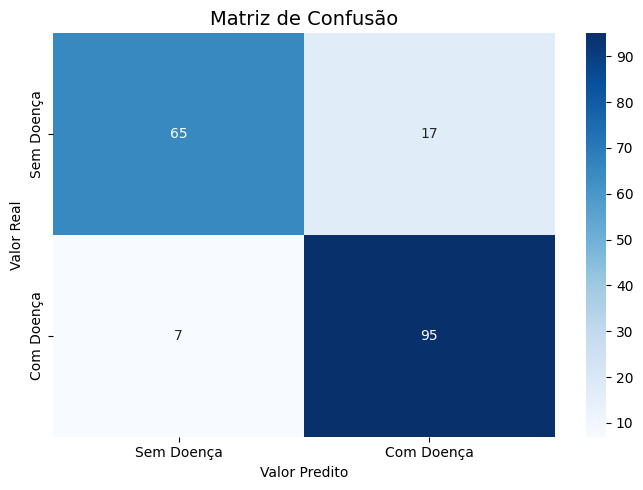

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Sem Doença', 'Com Doença'],
    yticklabels=['Sem Doença', 'Com Doença']
)
plt.title('Matriz de Confusão', fontsize=14)
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')
plt.tight_layout()
plt.show()

##Visualização da Função Sigmoide e Predições

A função sigmoide é plotada para ilustrar como a regressão logística transforma valores em probabilidades, destacando o limiar de decisão (0.5). Ao lado, são exibidas as probabilidades previstas no conjunto de teste, indicando a classificação entre pacientes com e sem doença.

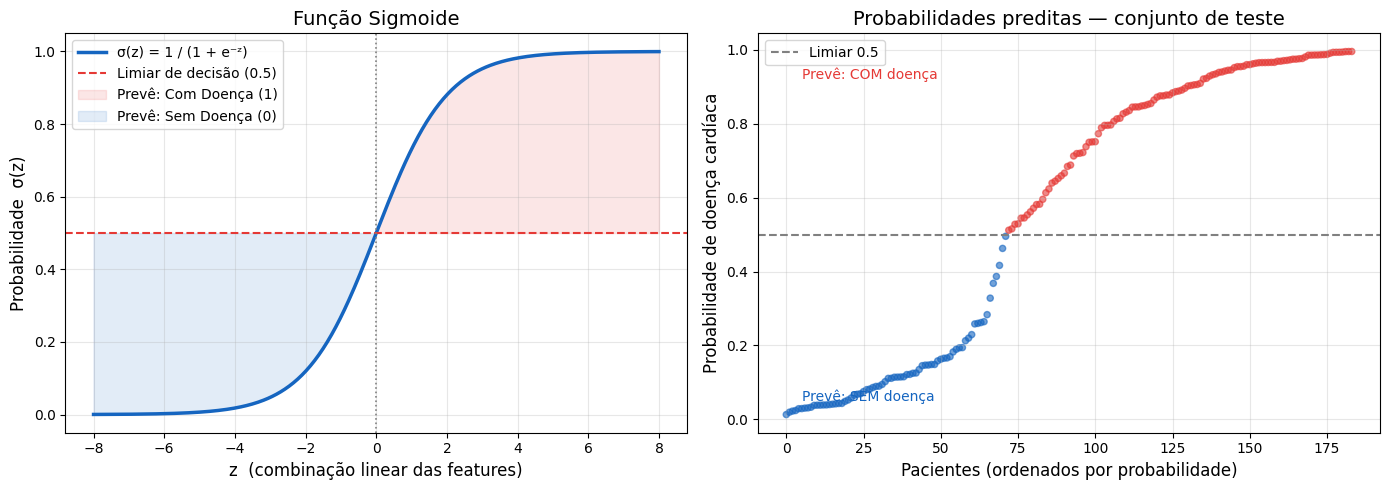

In [8]:
z = np.linspace(-8, 8, 400)
sigmoid = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(z, sigmoid, color='#1565C0', lw=2.5, label='σ(z) = 1 / (1 + e⁻ᶻ)')
axes[0].axhline(y=0.5, color='#E53935', linestyle='--', lw=1.5, label='Limiar de decisão (0.5)')
axes[0].axvline(x=0,   color='gray',    linestyle=':',  lw=1.2)

#
axes[0].fill_between(z, sigmoid, 0.5, where=(sigmoid > 0.5),
                     alpha=0.12, color='#E53935', label='Prevê: Com Doença (1)')
axes[0].fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5),
                     alpha=0.12, color='#1565C0', label='Prevê: Sem Doença (0)')

axes[0].set_xlabel('z  (combinação linear das features)', fontsize=12)
axes[0].set_ylabel('Probabilidade  σ(z)', fontsize=12)
axes[0].set_title('Função Sigmoide', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, alpha=0.3)

cores = ['#1565C0' if p < 0.5 else '#E53935' for p in y_prob]
axes[1].scatter(
    range(len(y_prob)),
    sorted(y_prob),
    c=sorted(cores, key=lambda c: y_prob[cores.index(c)]),
    alpha=0.6, s=20
)
axes[1].axhline(y=0.5, color='gray', linestyle='--', lw=1.5, label='Limiar 0.5')
axes[1].set_xlabel('Pacientes (ordenados por probabilidade)', fontsize=12)
axes[1].set_ylabel('Probabilidade de doença cardíaca', fontsize=12)
axes[1].set_title('Probabilidades preditas — conjunto de teste', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

axes[1].text(5,  0.92, 'Prevê: COM doença',  color='#E53935', fontsize=10)
axes[1].text(5,  0.05, 'Prevê: SEM doença',  color='#1565C0', fontsize=10)

plt.tight_layout()
plt.show()

##Análise dos Coeficientes do Modelo

Os coeficientes da regressão logística são extraídos e organizados para visualizar o impacto de cada variável na predição. Valores positivos indicam aumento do risco de doença, enquanto negativos indicam redução. Também é exibido um gráfico para facilitar a interpretação.

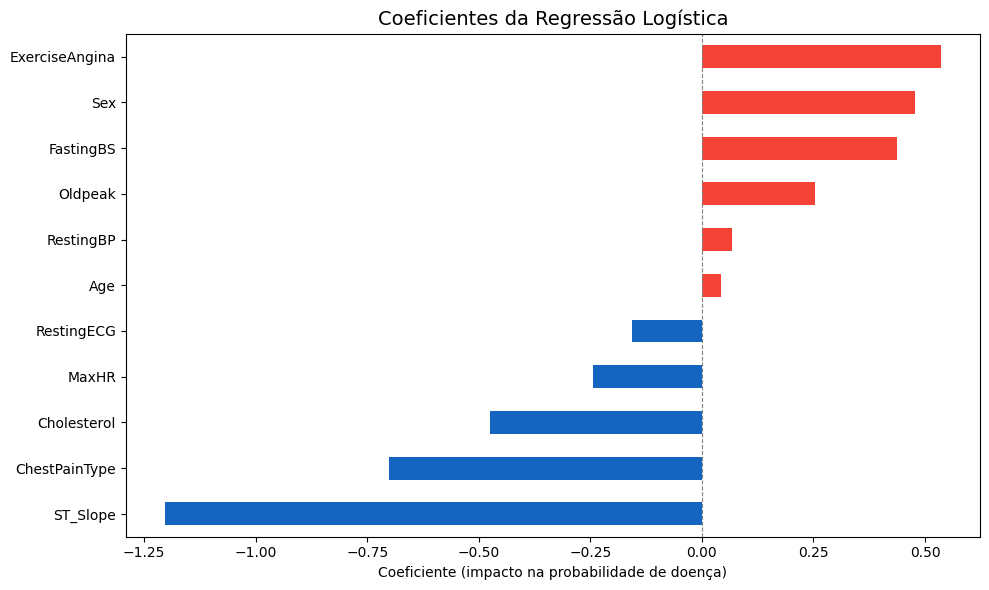

Features que AUMENTAM risco (coef. positivo):
ExerciseAngina    0.536199
Sex               0.476509
FastingBS         0.438204
Oldpeak           0.253479
RestingBP         0.067722
Age               0.042982

Features que REDUZEM risco (coef. negativo):
ST_Slope        -1.204104
ChestPainType   -0.702255
Cholesterol     -0.474871
MaxHR           -0.243404
RestingECG      -0.157095


In [9]:
coefs = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values()

colors = ['#F44336' if c > 0 else '#1565C0' for c in coefs]

plt.figure(figsize=(10, 6))
coefs.plot(kind='barh', color=colors)
plt.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Coeficientes da Regressão Logística', fontsize=14)
plt.xlabel('Coeficiente (impacto na probabilidade de doença)')
plt.tight_layout()
plt.show()

print('Features que AUMENTAM risco (coef. positivo):')
print(coefs[coefs > 0].sort_values(ascending=False).to_string())
print('\nFeatures que REDUZEM risco (coef. negativo):')
print(coefs[coefs < 0].sort_values().to_string())